In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\kriti\Downloads\train.csv")

In [13]:
df.head()

,Temperature Anomaly,Wind Speed Variation,Industrial Emission Index,Traffic Density Score,Change in AQI
0,0.891,0.899,-0.749,-0.933,-31.15
1,NaN,0.275,NaN,0.011,141.55
2,0.253,NaN,-1.725,0.405,NaN
3,-0.505,-0.768,-1.474,0.422,-145.55
4,0.693,1.019,NaN,1.538,167.65


In [6]:
print(df.shape)

(101766, 50)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [14]:
df.duplicated().sum()

np.int64(34)

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
#handling missing values
df["Temperature Anomaly"]=df["Temperature Anomaly"].fillna(df['Temperature Anomaly'].median())
df["Wind Speed Variation"]=df["Wind Speed Variation"].fillna(df['Wind Speed Variation'].mean())
df["Industrial Emission Index"]=df["Industrial Emission Index"].fillna(df['Industrial Emission Index'].median())
df["Traffic Density Score"]=df["Traffic Density Score"].fillna(df['Traffic Density Score'].mean())
df["Change in AQI"]=df["Change in AQI"].fillna(df['Change in AQI'].mean())

In [17]:
df.describe()

,Temperature Anomaly,Wind Speed Variation,Industrial Emission Index,Traffic Density Score,Change in AQI
count,734.000000,734.000000,734.000000,734.000000,734.000000
mean,-0.014846,-0.021979,0.040993,-0.082547,21.192274
std,0.971877,0.930603,0.949530,0.914092,104.034598
min,-2.636000,-2.888000,-2.857000,-3.394000,-285.350000
25%,-0.577500,-0.597750,-0.538000,-0.655000,-48.150000
50%,-0.019000,-0.021979,0.023000,-0.082547,21.192274
75%,0.613000,0.484500,0.577250,0.471500,87.500000
max,3.266000,3.135000,3.250000,2.865000,373.850000


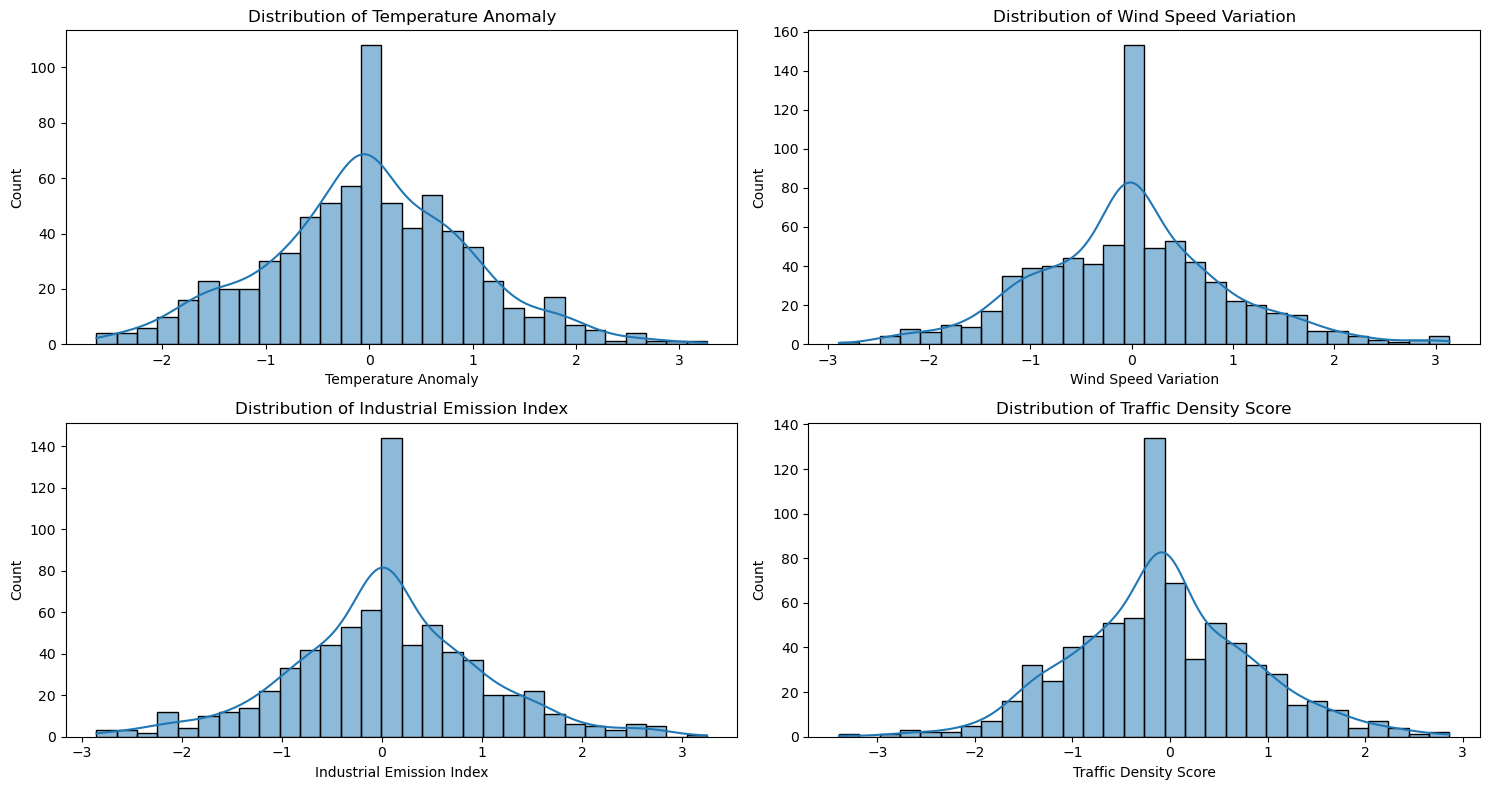

In [18]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(df.columns[:-1]):  # exclude target
    plt.subplot(2, (3+1)//2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

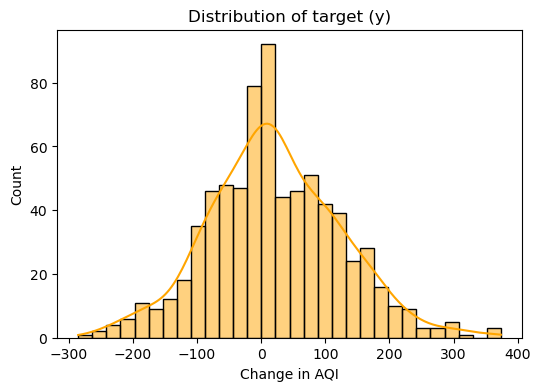

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df['Change in AQI'], kde=True, bins=30, color='orange')
plt.title("Distribution of target (y)")
plt.show()

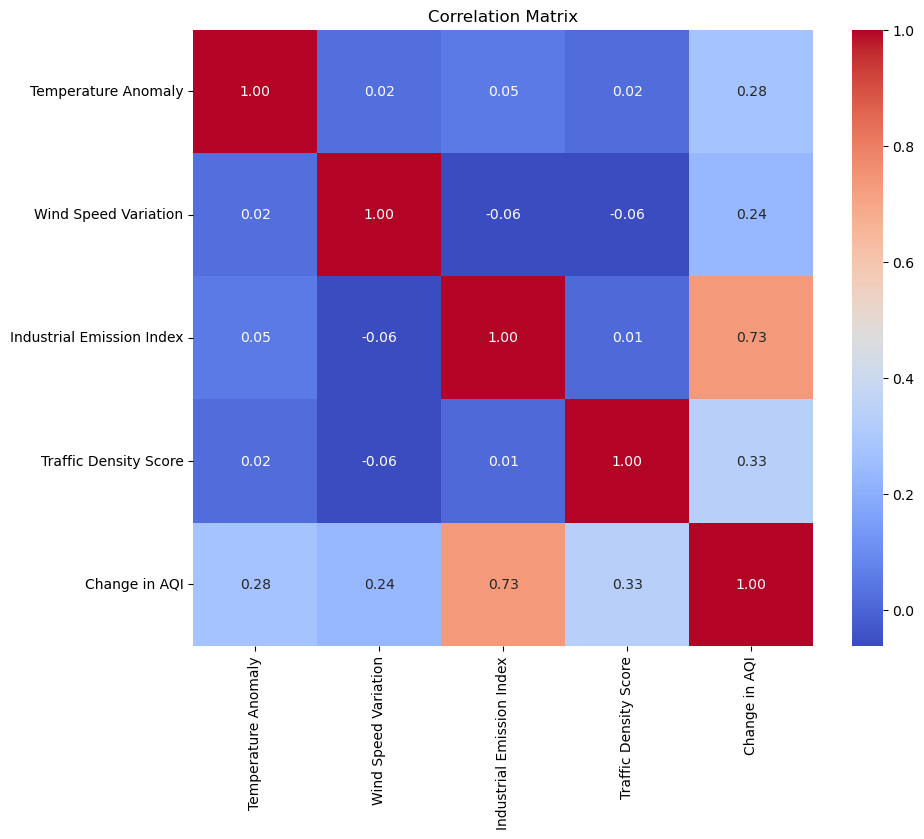

In [20]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [23]:
X = df.drop('Change in AQI', axis=1)
y = df['Change in AQI']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.fit(X, y)
y_pred_lr = lr.predict(X_val)

print("Linear Regression R2:", r2_score(y_val, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_val, y_pred_lr))

Linear Regression R2: 0.7023191302797838
Linear Regression MSE: 2186.773801019543


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
